In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
from fair import FAIR
from fair.interface import fill, initialise
from fair.io import read_properties

# FaIR analysis of California offsetting

We're interested in understanding how the cooling affect implied by the CO2e metric compares to the actual portfolio of multi-gas emission reductions. We use FaIR to compare temperature outcomes of: 

1. gas-specific offset project emissions reductions versus the "equivalent" CO2 reductions implied by the CO2e metric
2. the offsetting program as a whole (both project fluxes and offset-justified emissions)

# Get inputs

inputs:
- ca_project_fluxes.csv
- ca_justified_offset_fluxes.csv

scenarios:
- baseline: ssp2-4.5 only
- projects_only: ssp245 + credited project fluxes (supply side; physical emissions justified by using offsets)
- emissions_only: ssp245 + offset-justified emissions (demand side; physical project co2, ch4, and cfc-12 fluxes)
- net_program: ssp245 + offset-justified emissions + project fluxes


- claimed_project: baseline + project co2 fluxes + ch4 and cfc-12 project fluxes converted to co2e
- actual_ch4: baseline + physical ch4 project fluxes only
- claimed_ch4: baseline + ch4 project fluxes converted to co2e only
- actual_cfc-12: baseline + physical cfc-12 project fluxes only
- claimed_cfc-12: baseline + cfc-12 project fluxes converted to co2e only

In [75]:
# ----------------------------
# user inputs
# ----------------------------

PROJECTS_FILE = "../timeseries-data/output-data/ca_project_fluxes.csv"
EMISSIONS_FILE = "../timeseries-data/output-data/ca_justified_emissions_fluxes.csv"
BASELINE_SCENARIO = "ssp245"

# year-dependent gwp100 for ch4
def gwp_ch4(year):
    return 21 if year <= 2020 else 25

# gwp100 for cfc-12
gwp_cfc12 = 10900

In [77]:
# ----------------------------
# load data
# ----------------------------

df_p = pd.read_csv(PROJECTS_FILE)
df_p.columns = df_p.columns.str.lower()
df_p = df_p[["year", "co2_flux", "ch4_flux", "cfc-12_flux"]].sort_values("year").fillna(0)

df_e = pd.read_csv(EMISSIONS_FILE)
df_e.columns = df_e.columns.str.lower()
df_e = df_e[["year","co2_justified","ch4_justified", "n2o_justified"]].sort_values("year").fillna(0)

# Run FaIR simulations

In [78]:
# ----------------------------
# set up fair
# ----------------------------

f = FAIR()
f.define_time(1750, 2200, 1)
f.define_scenarios([
    BASELINE_SCENARIO,
    "emissions_only",
    "projects_only",
    "net_program",
    "claimed_project",
    "actual_ch4",
    "claimed_ch4",
    "actual_cfc12",
    "claimed_cfc12"
])
f.define_configs(["central"])

all_species, all_props = read_properties()

species = ["CO2 FFI", "CO2 AFOLU", "CH4", "N2O", "CFC-12", "CO2"]
properties = {s: all_props[s] for s in species}

properties["CO2 FFI"]["input_mode"] = "emissions"
properties["CO2 FFI"]["greenhouse_gas"] = False

properties["CO2 AFOLU"]["input_mode"] = "emissions"
properties["CO2 AFOLU"]["greenhouse_gas"] = False

properties["CH4"]["input_mode"] = "emissions"
properties["CH4"]["greenhouse_gas"] = True

properties["N2O"]["input_mode"] = "emissions"
properties["N2O"]["greenhouse_gas"] = True

properties["CFC-12"]["input_mode"] = "emissions"
properties["CFC-12"]["greenhouse_gas"] = True

properties["CO2"]["input_mode"] = "calculated"
properties["CO2"]["greenhouse_gas"] = True

f.define_species(species, properties)
f.allocate()
f.fill_species_configs()

# TK: what's the provenance of these configs? 

fill(f.climate_configs["ocean_heat_capacity"], [8.0, 14.0, 100.0], config="central")
fill(f.climate_configs["ocean_heat_transfer"], [1.1, 1.6, 0.9], config="central")
fill(f.climate_configs["deep_ocean_efficacy"], 1.1, config="central")

In [80]:
# ----------------------------
# load baseline emissions
# ----------------------------

backup = list(f.scenarios)
f.scenarios = [BASELINE_SCENARIO]
f.fill_from_rcmip()
f.scenarios = backup

for sp in ["CO2 FFI", "CO2 AFOLU", "CH4", "N2O", "CFC-12"]:
    base = f.emissions.sel(
        scenario=BASELINE_SCENARIO,
        config="central",
        specie=sp
    ).values

    for scen in ["emissions_only","projects_only","net_program", "claimed_project", "actual_ch4", "claimed_ch4", "actual_cfc12", "claimed_cfc12"]:
        fill(f.emissions, base, scenario=scen, config="central", specie=sp)

In [82]:
# ----------------------------
# apply project perturbations
# ----------------------------

timepoints = np.asarray(f.timepoints, dtype=float)

for _, row in df_p.iterrows():

    year = float(row["year"])
    i = np.argmin(np.abs(timepoints - year))
    yr = timepoints[i]

    # convert units
    co2_p = row["co2_flux"] / 1e9       # Conversion from ton to gigaton
    ch4_p = row["ch4_flux"] / 1e6       # Conversion from ton to megaton
    cfc12_p = row["cfc-12_flux"] / 1e3  # Conversion from ton to kilaton

    # projects_only + net program: all project fluxes enter as physical gases
    for scen in ["projects_only", "net_program"]:
        f.emissions.loc[dict(timepoints=yr, scenario=scen, config="central", specie="CO2 FFI")].values += co2_p
        f.emissions.loc[dict(timepoints=yr, scenario=scen, config="central", specie="CH4")].values += ch4_p
        f.emissions.loc[dict(timepoints=yr, scenario=scen, config="central", specie="CFC-12")].values += cfc12_p

    # claimed_project: co2 project fluxes + ch4 and cfc12 project fluxes represented as co2-equivalent
    f.emissions.loc[dict(timepoints=yr, scenario="claimed_project", config="central", specie="CO2 FFI")].values += co2_p + ch4_p * gwp_ch4(year) / 1000 + cfc12_p * gwp_cfc12 / 1e6

    # actual_ch4: only physical ch4 project flux
    f.emissions.loc[dict(timepoints=yr, scenario="actual_ch4", config="central", specie="CH4")].values += ch4_p

    # claimed_ch4: only ch4 project flux represented as co2-equivalent
    f.emissions.loc[dict(timepoints=yr, scenario="claimed_ch4", config="central", specie="CO2 FFI")].values += ch4_p * gwp_ch4(year) / 1000

    # actual_cfc12: only physical cfc-12 project flux
    f.emissions.loc[dict(timepoints=yr, scenario="actual_cfc12", config="central", specie="CFC-12")].values += cfc12_p

    # claimed_cfc12: only cfc-12 flux represented as co2-equivalent
    f.emissions.loc[dict(timepoints=yr, scenario="claimed_cfc12", config="central", specie="CO2 FFI")].values += cfc12_p * gwp_cfc12 / 1e6

In [83]:
# ----------------------------
# apply offset-justified emissions
# ----------------------------

for _, row in df_e.iterrows():

    year = float(row["year"])
    i = np.argmin(np.abs(timepoints - year))
    yr = timepoints[i]

    co2_e = row["co2_justified"] / 1e9
    ch4_e = row["ch4_justified"] / 1e6
    n2o_e = row["n2o_justified"] / 1e6

    # emissions_only + net program: all justified emissions fluxes enter as physical gases
    for scen in ["emissions_only", "net_program"]:
        f.emissions.loc[dict(timepoints=yr, scenario=scen, config="central", specie="CO2 FFI")].values += co2_e
        f.emissions.loc[dict(timepoints=yr, scenario=scen, config="central", specie="CH4")].values += ch4_e
        f.emissions.loc[dict(timepoints=yr, scenario=scen, config="central", specie="N2O")].values += n2o_e


In [84]:
# ----------------------------
# initialise + run
# ----------------------------

initialise(f.concentration, 278.0, specie="CO2")
initialise(f.concentration, 730.0, specie="CH4")
initialise(f.concentration, 270.0, specie="N2O")
initialise(f.concentration, 0.0, specie="CFC-12")

initialise(f.forcing, 0.0)
initialise(f.temperature, 0.0)
initialise(f.cumulative_emissions, 0.0)
initialise(f.airborne_emissions, 0.0)
initialise(f.ocean_heat_content_change, 0.0)

f.run()

Running 9 projections in parallel:   0%|          | 0/450 [00:00<?, ?timesteps/s]

# Exploring program temp impact

As a starting point, we can explore how the cooling affect of the project fluxes and the warming affect of justified emissions combine into a program-wide temperature impact

In [88]:
# ----------------------------
# extract temperature trajectories
# ----------------------------

years = np.asarray(f.timebounds, dtype=float)
baseline = f.temperature.loc[dict(scenario=BASELINE_SCENARIO, config="central", layer=0)]
emissions_only = f.temperature.loc[dict(scenario="emissions_only", config="central", layer=0)]
projects_only = f.temperature.loc[dict(scenario="projects_only", config="central", layer=0)]
net_program = f.temperature.loc[dict(scenario="net_program", config="central", layer=0)]


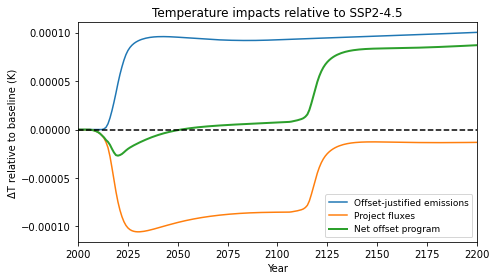

In [87]:
plt.figure(figsize=(7,4))

plt.plot(years, emissions_only - baseline, label="Offset-justified emissions")
plt.plot(years, projects_only - baseline, label="Project fluxes")
plt.plot(years, net_program - baseline, label="Net offset program", linewidth=2)

plt.axhline(0, ls="--", color="k")
plt.xlim(2000,2200)
plt.xlabel("Year")
plt.ylabel("ΔT relative to baseline (K)")
plt.title("Temperature impacts relative to SSP2-4.5")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

We can also determine in which years in which the program as a whole begins provide more or less of a cooling effect than implied by the co2e equivalent offsetting logic — i.e. "crossover years". (Note, this is a picture of the program activity to date and it's impact over time with no assumptions about ongoing or future activity.)

In [67]:
diff = net_program - baseline
crossover_years = years[:-1][np.diff(np.sign(diff)) != 0]
print(crossover_years.astype(int))

[2004 2053]


It's striking that the program as a whole becomes net warming by 2053. This could driven by a number of factors including: 

1. the composition of justified emissions (what's different if all justified emissions are co2?)
2. the gwp100 conversion (what's the temperature trajectory difference between each constituent project flux gas and the "equivalent" quantity of co2 reductions?) 
3. the choice of equivalency metric (what would have been different if gwp20, gtp50, gtp100, or like-for-like logic had been applied instead of gwp100?) 

We'll explore each in turn. 

## 01 — impact of justified emissions composition

## 02 — impact of the gwp100 conversion

In [94]:
# extract temperature trajectories
years = np.asarray(f.timebounds, dtype=float)

baseline = f.temperature.loc[dict(scenario=BASELINE_SCENARIO, config="central", layer=0)]
actual = f.temperature.loc[dict(scenario="projects_only", config="central", layer=0)]
claimed = f.temperature.loc[dict(scenario="claimed_project", config="central", layer=0)]
actual_ch4_t = f.temperature.loc[dict(scenario="actual_ch4", config="central", layer=0)]
claimed_ch4_t = f.temperature.loc[dict(scenario="claimed_ch4", config="central", layer=0)]
actual_cfc12_t = f.temperature.loc[dict(scenario="actual_cfc12", config="central", layer=0)]
claimed_cfc12_t = f.temperature.loc[dict(scenario="claimed_cfc12", config="central", layer=0)]

In [96]:
# extract emissions data 

years_e = np.asarray(f.timepoints, dtype=float)

baseline_co2   = f.emissions.loc[dict(scenario=BASELINE_SCENARIO, config="central", specie="CO2 FFI")]
baseline_ch4   = f.emissions.loc[dict(scenario=BASELINE_SCENARIO, config="central", specie="CH4")]
baseline_cfc12 = f.emissions.loc[dict(scenario=BASELINE_SCENARIO, config="central", specie="CFC-12")]
actual_co2_emis = f.emissions.loc[dict(scenario="projects_only", config="central", specie="CO2 FFI")]

actual_ch4_emis        = f.emissions.loc[dict(scenario="projects_only", config="central", specie="CH4")]
actual_cfc12_emis      = f.emissions.loc[dict(scenario="projects_only", config="central", specie="CFC-12")]

actual_co2_only_emis   = f.emissions.loc[dict(scenario="projects_only", config="central", specie="CO2 FFI")]
actual_ch4_only_emis   = f.emissions.loc[dict(scenario="actual_ch4", config="central", specie="CH4")]
actual_cfc12_only_emis = f.emissions.loc[dict(scenario="actual_cfc12", config="central", specie="CFC-12")]

claimed_co2_only_co2   = f.emissions.loc[dict(scenario="claimed_project", config="central", specie="CO2 FFI")]
claimed_ch4_only_co2   = f.emissions.loc[dict(scenario="claimed_ch4", config="central", specie="CO2 FFI")]
claimed_cfc12_only_co2 = f.emissions.loc[dict(scenario="claimed_cfc12", config="central", specie="CO2 FFI")]

As a starting point, we can compare the cooling affect of the actual portfolio of offset project fluxes versus the claimed cooling effect of an "equivalent" CO2 flux.

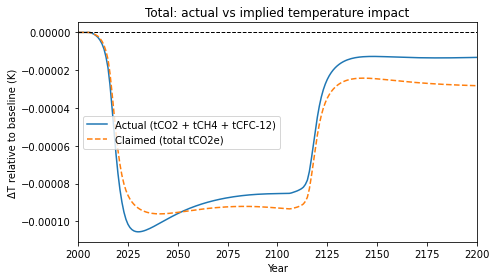

In [98]:
plt.figure(figsize=(7, 4))
plt.plot(years, projects_only - baseline,  label="Actual (tCO2 + tCH4 + tCFC-12)")
plt.plot(years, claimed - baseline, "--", label="Claimed (total tCO2e)")
plt.axhline(0, linestyle="--", linewidth=1, color='k')
plt.xlim(2000, 2200)
plt.xlabel("Year")
plt.ylabel("ΔT relative to baseline (K)")
plt.title("Total: actual vs implied temperature impact")
plt.legend()
plt.tight_layout()
plt.show()

In [99]:
diff = actual - claimed
crossover_years = years[:-1][np.diff(np.sign(diff)) != 0]
print(crossover_years.astype(int))

[2005 2051]


We can explore what underpins the early cooling to long-term warming trend by examining ch4 and cfc-12 individually. 

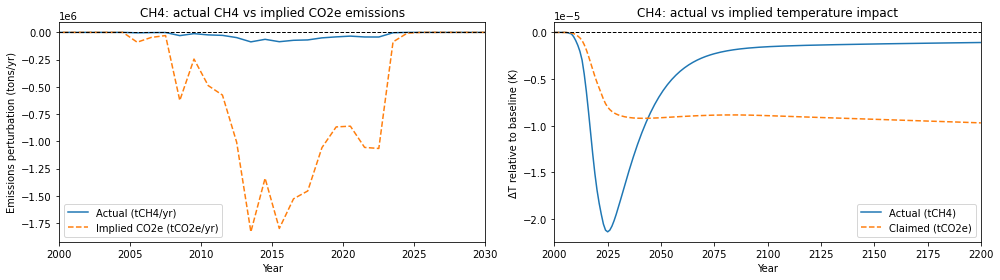

[2005 2043]


In [100]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# --- CH4 emissions: actual vs implied CO2e flux ---
ax1.plot(years_e, (actual_ch4_only_emis - baseline_ch4) * 1e6,      label="Actual (tCH4/yr)")
ax1.plot(years_e, (claimed_ch4_only_co2 - baseline_co2) * 1e9, "--", label="Implied CO2e (tCO2e/yr)")
ax1.axhline(0, linestyle="--", linewidth=1, color='k')
ax1.set_xlim(2000, 2030)
ax1.set_xlabel("Year")
ax1.set_ylabel("Emissions perturbation (tons/yr)")
ax1.set_title("CH4: actual CH4 vs implied CO2e emissions")
ax1.legend()

# --- CH4 component temperature: actual vs claimed ---
ax2.plot(years, actual_ch4_t  - baseline, label="Actual (tCH4)")
ax2.plot(years, claimed_ch4_t - baseline, "--", label="Claimed (tCO2e)")
ax2.axhline(0, linestyle="--", linewidth=1, color='k')
ax2.set_xlim(2000, 2200)
ax2.set_xlabel("Year")
ax2.set_ylabel("ΔT relative to baseline (K)")
ax2.set_title("CH4: actual vs implied temperature impact")
ax2.legend()

plt.tight_layout()
plt.show()

# --- determine crossover years ---
diff = (actual_ch4_t  - baseline) - (claimed_ch4_t - baseline)
crossover_years = years[:-1][np.diff(np.sign(diff)) != 0]
print(crossover_years.astype(int))

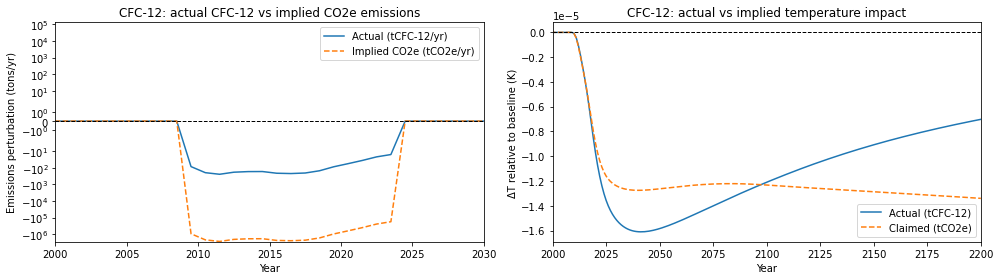

[2015 2097]


In [101]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# --- CFC-12 emissions: actual vs implied CO2e flux ---
ax1.plot(years_e, (actual_cfc12_only_emis - baseline_cfc12) * 1e3,      label="Actual (tCFC-12/yr)")
ax1.plot(years_e, (claimed_cfc12_only_co2 - baseline_co2) * 1e9, "--", label="Implied CO2e (tCO2e/yr)")
ax1.axhline(0, linestyle="--", linewidth=1, color='k')
ax1.set_xlim(2000, 2030)
ax1.set_yscale("symlog")
ax1.set_xlabel("Year")
ax1.set_ylabel("Emissions perturbation (tons/yr)")
ax1.set_title("CFC-12: actual CFC-12 vs implied CO2e emissions")
ax1.legend()

# --- CFC-12 component temperature: actual vs claimed ---
ax2.plot(years, actual_cfc12_t  - baseline, label="Actual (tCFC-12)")
ax2.plot(years, claimed_cfc12_t - baseline, "--", label="Claimed (tCO2e)")
ax2.axhline(0, linestyle="--", linewidth=1, color='k')
ax2.set_xlim(2000, 2200)
ax2.set_xlabel("Year")
ax2.set_ylabel("ΔT relative to baseline (K)")
ax2.set_title("CFC-12: actual vs implied temperature impact")
ax2.legend()

plt.tight_layout()
plt.show()

# --- determine crossover years ---
diff = (actual_cfc12_t  - baseline) - (claimed_cfc12_t - baseline)
crossover_years = years[:-1][np.diff(np.sign(diff)) != 0]
crossover_years = crossover_years[crossover_years > 2010]
print(crossover_years.astype(int))

## 03 — impact of the equivalency metric choice